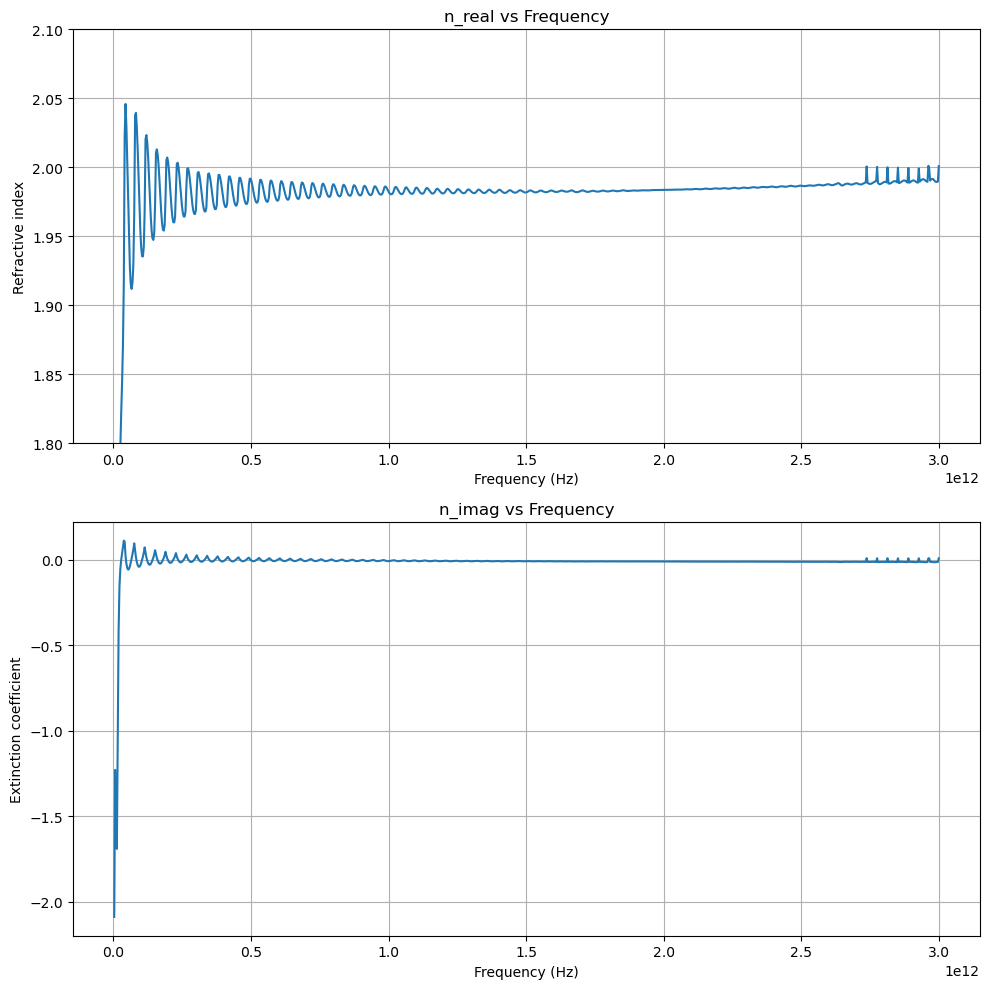

In [9]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# LOAD DATA
datar = np.loadtxt("2mmR.dat", delimiter=",")
datas = np.loadtxt("2mmS.dat", delimiter=",")
ts = datas[:, 0]
tr = datar[:, 0]
sr = datar[:, 1]
ss = datas[:, 1]

# INTERPOLATION
startt = 0
endt = 4.6116 * 10**-11
dt = min(np.mean(np.diff(ts)), np.mean(np.diff(tr)))
t = np.arange(startt, endt + dt, dt)

sr = np.interp(t, tr, sr, left=0, right=0)
ss = np.interp(t, ts, ss, left=0, right=0)

# FFT
fftr = np.fft.fft(sr, 16384)
ffts = np.fft.fft(ss, 16384)
freq = np.fft.fftfreq(16384, dt)

# MASK
mask = (freq > 0) & (freq < 3 * 10**12)
fftr = fftr[mask]
ffts = ffts[mask]
freq = freq[mask]

# TRANSFER FUNCTION 
tf_exp = ffts / fftr

L = 2e-3  
c = 3e8   

freq_t = torch.tensor(freq, dtype=torch.float32)
H_exp_t = torch.tensor(tf_exp, dtype=torch.complex64)

n_init = 2.0  
k_init = 0.005  
n_t = torch.full_like(freq_t, n_init, dtype=torch.float32, requires_grad=True)
k_t = torch.full_like(freq_t, k_init, dtype=torch.float32, requires_grad=True)

# === NEW PHYSICS-BASED H_th FUNCTION ===
def H_th_t(n, k, freq):
    n_complex = n + 1j * k
    n0 = 1.0
    omega = 2 * torch.pi * freq

    r01 = (n_complex - n0) / (n_complex + n0)
    amp_term = (4 * n_complex * n0) / (n_complex + n0) ** 2
    phase_term = torch.exp(-1j * omega * L * (n_complex - n0) / c)
    multi_reflection = 1 - (r01 ** 2) * torch.exp(-2j * omega * n_complex * L / c)

    return amp_term * phase_term * multi_reflection

# Loss Function
def loss_function(H_theo, H_exp):
    return torch.mean((torch.real(H_theo) - torch.real(H_exp)) ** 2) + \
           torch.mean((torch.imag(H_theo) - torch.imag(H_exp)) ** 2)

# Optimization Function
def opt(freq, H_exp, n, k, learning_rate=0.001, num_iterations=2000):
    optimizer = torch.optim.Adam([n, k], lr=learning_rate)

    for i in range(num_iterations):
        optimizer.zero_grad()
        H_theo = H_th_t(n, k, freq)
        loss = loss_function(H_theo, H_exp)
        loss.backward()
        optimizer.step()

    return n.detach().numpy(), k.detach().numpy()

# Run Optimization
n_opt, k_opt = opt(freq_t, H_exp_t, n_t, k_t)

# Save Results
output_data = np.column_stack((freq, n_opt, k_opt))
np.savetxt("n_k_inf.txt", output_data, header="Frequency(Hz) n_real k_imag", fmt="%.6e")

# Plot Results
plt.figure(figsize=(10, 10))

plt.subplot(2, 1, 1)
plt.plot(freq, n_opt)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Refractive index")
plt.title("n_real vs Frequency")
plt.ylim(1.8, 2.1)
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(freq, k_opt)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Extinction coefficient")
plt.title("n_imag vs Frequency")
plt.grid(True)

plt.tight_layout()
plt.show()
